## RNN Pipeline Overview

This notebook implements a vanilla Recurrent Neural Network (RNN) for character-level language modeling. Below is a breakdown of the core mechanics, mapping the theoretical principles from the Vizuara AI Pods RNN Article directly to this PyTorch implementation.

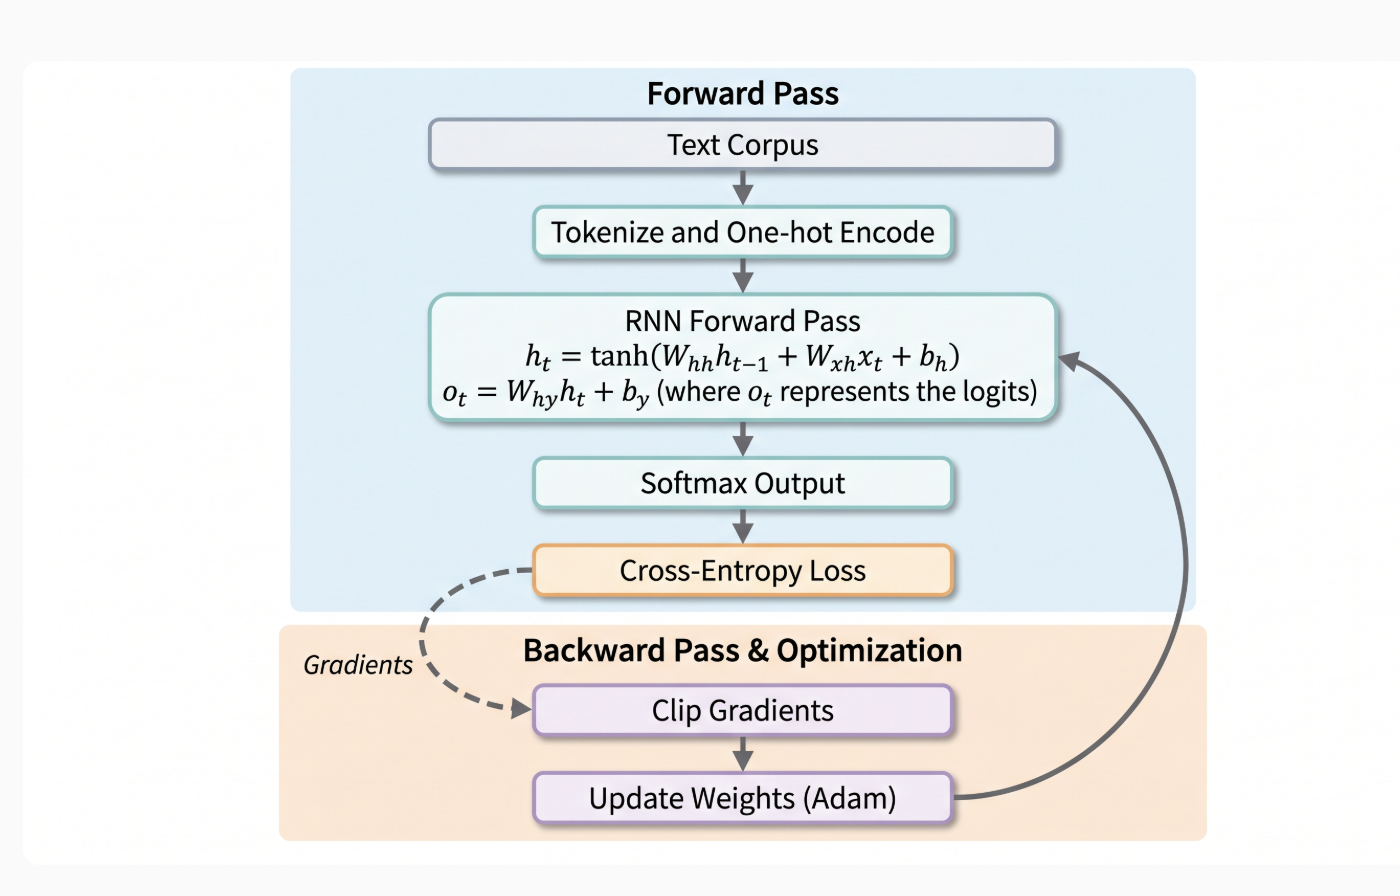

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random

In [2]:
# ── 1. Dataset ────────────────────────────────────────────────────────────────
text = (
    "call me ishmael some years ago never mind how long precisely "
    "having little or no money in my purse and nothing particular "
    "to interest me on shore i thought i would sail about a little "
    "and see the watery part of the world"
)

In [17]:
# Build vocabulary
chars   = sorted(set(text))
vocab   = {ch: i for i, ch in enumerate(chars)}
inv_vocab = {i: ch for ch, i in vocab.items()}
V = len(chars)
print(f"Vocabulary size: {V}  |  Text length: {len(text)}")

Vocabulary size: 22  |  Text length: 220


In [18]:
def one_hot(idx, size):
    v = torch.zeros(size)
    v[idx] = 1.0
    return v

In [23]:
### Encoding text as indices
data=[vocab[ch] for ch in text]

## 🧱 1. Model Architecture & The Logit Concept

Our `CharRNN` consists of three core components working together:
1. **An Embedding/Input Layer:** Expects a sequence of one-hot encoded characters of shape `(batch_size, sequence_length, vocab_size)`.
2. **The Recurrent Core (`nn.RNN`):** Tracks temporal dependencies by passing its hidden state $h_t$ from one step to the next.
3. **The Linear Head (`nn.Linear`):** Maps the hidden states back to our vocabulary size $V$.

### ⚠️ What are Logits?
The final linear layer outputs **logits**—raw, unnormalized scores ranging from $-\infty$ to $+\infty$.
* **Logits are NOT probabilities.** They can be negative, and they do not sum to $1.0$.
* **Why keep them raw?** During training, PyTorch's `F.cross_entropy` loss function expects raw logits. It automatically computes a mathematically stable `LogSoftmax` under the hood. Hardcoding a Softmax inside the `forward` pass would break training gradients!

In [56]:
### Model###

class CharRNN(nn.Module):
  def __init__(self,vocab_size,hidden_size):
    super().__init__()
    self.hidden_size = hidden_size
    self.rnn=nn.RNN(vocab_size,hidden_size,batch_first=True)
    self.head=nn.Linear(hidden_size,vocab_size)

  def forward(self,x_seq,h0=None):
    out,hn=self.rnn(x_seq,h0)
    logits=self.head(out)
    return logits,hn


  # New helper method used ONLY for text generation
  def get_probs(self, x_seq, h0=None, temperature=0.8):
    logits, hn = self.forward(x_seq, h0)
    probs = F.softmax(logits.squeeze() / temperature, dim=-1)
    return probs, hn

model=CharRNN(vocab_size=V,hidden_size=64)
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)


### 🔄 Training vs. Generation: The `get_probs` Helper

To keep our architecture clean and production-ready, we separate our forward-pass logic:
* **`forward(x_seq, h0)`**: Used by the training loop. Returns raw logits directly to the loss function.
* **`get_probs(x_seq, h0, temperature)`**: Dedicated helper used *only* during text generation.

When text generation calls `model.get_probs(...)`, it automatically triggers the underlying standard `forward` pass to fetch the logits, scales them using our `temperature` parameter, and runs `F.softmax()` to output clean, ready-to-sample probabilities.

In [57]:
model

CharRNN(
  (rnn): RNN(22, 64, batch_first=True)
  (head): Linear(in_features=64, out_features=22, bias=True)
)

In [32]:
len(data)

220

In [41]:
SEQ_LEN = 25
start=random.randint(0, len(data) - SEQ_LEN - 2)
inp_idx = data[start    : start + SEQ_LEN]
tgt_idx = data[start + 1: start + SEQ_LEN + 1]

In [40]:
torch.stack([one_hot(i, V) for i in inp_idx]).unsqueeze(0)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.])

In [43]:
torch.tensor(tgt_idx)

tensor([14, 18, 15, 16,  5,  0,  1, 12,  4,  0, 12, 13, 17,  8,  9, 12,  7,  0,
        14,  1, 15, 17,  9,  3, 18])

## 🎛️ 3. Sequence Training Mechanics

Our training loop feeds text chunks of `SEQ_LEN = 25` characters into the GPU.

* **Input vs. Target Alignment:** The input (`inp_idx`) and target (`tgt_idx`) are the exact same slices of text, shifted right by exactly 1 character index.
* **Parallel Loss Processing:** Even though the whole 25-character sequence is calculated at once to maximize GPU acceleration, the RNN unrolls sequentially through time internally. At time step $t$, the prediction is evaluated **only** against its matching target index at position $t$.
* **Memory Optimization:** Notice that inputs are converted to `one_hot` vectors (so the network can do matrix multiplication), but targets remain raw integers. `F.cross_entropy` utilizes raw target integers to perform a fast, direct array index look-up rather than wasting system memory creating large sparse one-hot target matrices.

In [54]:
# ── 3. Training loop ──────────────────────────────────────────────────────────
SEQ_LEN = 25
EPOCHS  = 500

for epoch in range(1, EPOCHS + 1):
    # Random starting position in the text
    start = random.randint(0, len(data) - SEQ_LEN - 2)
    inp_idx = data[start    : start + SEQ_LEN]
    tgt_idx = data[start + 1: start + SEQ_LEN + 1]

    # Build one-hot input tensor: (1, SEQ_LEN, V)
    x_seq  = torch.stack([one_hot(i, V) for i in inp_idx]).unsqueeze(0)
    targets = torch.tensor(tgt_idx)         # (SEQ_LEN,)

    optimizer.zero_grad()
    logits, _ = model(x_seq)               # (1, SEQ_LEN, V)
    loss = F.cross_entropy(
        logits.squeeze(0),                 # (SEQ_LEN, V)
        targets
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
    optimizer.step()

    if epoch in (1, 15, 30,60,90,120,500):
        print(f"Epoch {epoch:2d}  |  Loss: {loss.item():.4f}")

Epoch  1  |  Loss: 1.0145
Epoch 15  |  Loss: 0.7891
Epoch 30  |  Loss: 0.8253
Epoch 60  |  Loss: 0.7394
Epoch 90  |  Loss: 0.8280
Epoch 120  |  Loss: 0.7577
Epoch 500  |  Loss: 0.3557


In [58]:
def generate(model, seed_char, length=80, temperature=0.8):
    model.eval()
    with torch.no_grad():
        idx = vocab.get(seed_char, 0)
        x   = one_hot(idx, V).unsqueeze(0).unsqueeze(0)   # (1,1,V)
        h   = None
        out_chars = [seed_char]

        for _ in range(length):
            # 1. Your model directly gives you the ready-to-use probabilities!
            probs, h = model.get_probs(x, h, temperature=temperature)

            # 2. You just roll the loaded die and keep moving
            next_idx = torch.multinomial(probs, 1).item()
            out_chars.append(inv_vocab[next_idx])
            x = one_hot(next_idx, V).unsqueeze(0).unsqueeze(0)

    return "".join(out_chars)

In [59]:
print("\nGenerated text (temperature=0.8):")
print(generate(model, seed_char='c', length=120))


Generated text (temperature=0.8):
cdrl dptn ndtmgvnalgygtoflnwccpnm ecpoybyrumerbebtncbn nalauvh spgyhuaonwbnrssiniphaypv vcpnurnwnygophvdnitsy fblrwnbd rn
